# Comprensión del Dataset - Gender Classifier

**Objetivo:** Explorar y comprender el dataset `gender-classifier-DFE-791531.csv`, que contiene datos de perfiles de Twitter etiquetados por género.

**Preguntas a responder:**
1. ¿Qué información presenta el dataset? Describir las principales características.
2. ¿Cómo se distribuye la variable objetivo `gender`?
3. ¿Qué correlaciones existen entre las variables numéricas?
4. ¿Cuál es el estado de los datos faltantes?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

SEED = 42
np.random.seed(SEED)

## 1. Carga del Dataset

In [2]:
import os

# Ruta compatible con Docker (JupyterLab) y VSCode (workspace root)
_candidates = [
    "data/gender-classifier-DFE-791531.csv",                 # VSCode (CWD = workspace root)
    "../data/gender-classifier-DFE-791531.csv",              # JupyterLab (CWD = jupyter/)
    "/app/data/gender-classifier-DFE-791531.csv",            # Docker absoluto
]
DATA_PATH = next(p for p in _candidates if os.path.exists(p))

df = pd.read_csv(DATA_PATH, encoding="latin-1")
print(f"Archivo cargado desde: {DATA_PATH}")
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(3)

Archivo cargado desde: ../data/gender-classifier-DFE-791531.csv
Dimensiones del dataset: 20050 filas x 26 columnas


,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,description,fav_number,gender_gold,link_color,name,profile_yn_gold,profileimage,retweet_count,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0000,yes,1.0,12/5/13 1:48,i sing my own rhythm.,0,NaN,08C2C2,sheezy0,NaN,https://pbs.twimg.com/profile_images/414342229...,0,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0000,yes,1.0,10/1/12 13:51,I'm the author of novels filled with family dr...,68,NaN,0084B4,DavdBurnett,NaN,https://pbs.twimg.com/profile_images/539604221...,0,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada)
2,815719228,False,finalized,3,10/26/15 23:33,male,0.6625,yes,1.0,11/28/14 11:30,louis whining and squealing and all,7696,NaN,ABB8C2,lwtprettylaugh,NaN,https://pbs.twimg.com/profile_images/657330418...,1,C0DEED,i absolutely adore when louis starts the songs...,NaN,5617,10/26/15 12:40,6.587300e+17,clcncl,Belgrade


## 2. Información General del Dataset

El dataset proviene de la plataforma CrowdFlower (Data For Everyone) y contiene perfiles de Twitter clasificados por género a través de crowdsourcing.

**Columnas principales:**

| Columna | Descripción |
|---|---|
| `_unit_id` | Identificador único del registro |
| `gender` | **Variable objetivo** — género asignado: `male`, `female`, `brand`, `unknown` |
| `gender:confidence` | Nivel de confianza de la anotación de género (0 a 1) |
| `profile_yn` | Si el usuario tiene perfil completo (`yes`/`no`) |
| `description` | Biografía del usuario en Twitter |
| `fav_number` | Número de favoritos del usuario |
| `link_color` | Color del enlace del perfil (hex) |
| `name` | Nombre de usuario |
| `retweet_count` | Cantidad de retweets |
| `sidebar_color` | Color del sidebar del perfil (hex) |
| `text` | Texto del tweet |
| `tweet_count` | Número total de tweets |
| `tweet_location` | Ubicación del tweet |
| `user_timezone` | Zona horaria del usuario |

In [3]:
print("=== Tipos de datos ===")
print(df.dtypes)
print(f"\n=== Columnas ({len(df.columns)}) ===")
print(list(df.columns))

=== Tipos de datos ===
_unit_id                   int64
_golden                     bool
_unit_state                  str
_trusted_judgments         int64
_last_judgment_at            str
gender                       str
gender:confidence        float64
profile_yn                   str
profile_yn:confidence    float64
created                      str
description                  str
fav_number                 int64
gender_gold                  str
link_color                   str
name                         str
profile_yn_gold              str
profileimage                 str
retweet_count              int64
sidebar_color                str
text                         str
tweet_coord                  str
tweet_count                int64
tweet_created                str
tweet_id                 float64
tweet_location               str
user_timezone                str
dtype: object

=== Columnas (26) ===
['_unit_id', '_golden', '_unit_state', '_trusted_judgments', '_last_judgment_at', 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20050 entries, 0 to 20049
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   _unit_id               20050 non-null  int64  
 1   _golden                20050 non-null  bool   
 2   _unit_state            20050 non-null  str    
 3   _trusted_judgments     20050 non-null  int64  
 4   _last_judgment_at      20000 non-null  str    
 5   gender                 19953 non-null  str    
 6   gender:confidence      20024 non-null  float64
 7   profile_yn             20050 non-null  str    
 8   profile_yn:confidence  20050 non-null  float64
 9   created                20050 non-null  str    
 10  description            16306 non-null  str    
 11  fav_number             20050 non-null  int64  
 12  gender_gold            50 non-null     str    
 13  link_color             20050 non-null  str    
 14  name                   20050 non-null  str    
 15  profile_yn_go

## 3. Análisis de Valores Faltantes

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Faltantes": missing, "Porcentaje (%)": missing_pct})
missing_df = missing_df[missing_df["Faltantes"] > 0].sort_values("Porcentaje (%)", ascending=False)
print(f"Columnas con valores faltantes: {len(missing_df)} de {len(df.columns)}")
missing_df

Columnas con valores faltantes: 9 de 26


,Faltantes,Porcentaje (%)
gender_gold,20000,99.75
profile_yn_gold,20000,99.75
tweet_coord,19891,99.21
user_timezone,7798,38.89
tweet_location,7485,37.33
description,3744,18.67
gender,97,0.48
_last_judgment_at,50,0.25
gender:confidence,26,0.13


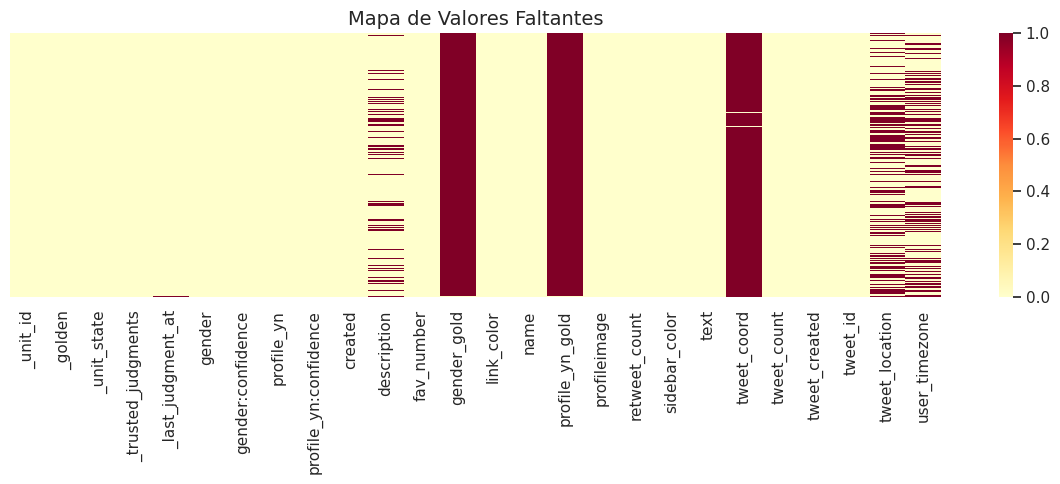

In [6]:
# Visualización de valores faltantes
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="YlOrRd", ax=ax)
ax.set_title("Mapa de Valores Faltantes", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Estadísticas Descriptivas

In [7]:
df.describe()

,_unit_id,_trusted_judgments,gender:confidence,profile_yn:confidence,fav_number,retweet_count,tweet_count,tweet_id
count,2.005000e+04,20050.000000,20024.000000,20050.000000,20050.000000,20050.000000,2.005000e+04,2.005000e+04
mean,8.157294e+08,3.615711,0.882756,0.993221,4382.201646,0.079401,3.892469e+04,6.587350e+17
std,6.000801e+03,12.331890,0.191403,0.047168,12518.575919,2.649751,1.168371e+05,5.000124e+12
min,8.157192e+08,3.000000,0.000000,0.627200,0.000000,0.000000,1.000000e+00,6.587300e+17
25%,8.157243e+08,3.000000,0.677800,1.000000,11.000000,0.000000,2.398000e+03,6.587300e+17
50%,8.157294e+08,3.000000,1.000000,1.000000,456.000000,0.000000,1.144150e+04,6.587300e+17
75%,8.157345e+08,3.000000,1.000000,1.000000,3315.500000,0.000000,4.002750e+04,6.587400e+17
max,8.157580e+08,274.000000,1.000000,1.000000,341621.000000,330.000000,2.680199e+06,6.587400e+17


In [8]:
# Estadísticas de variables categóricas
df.describe(include="object")

/tmp/ipykernel_897/1164085477.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,_unit_state,_last_judgment_at,gender,profile_yn,created,description,gender_gold,link_color,name,profile_yn_gold,profileimage,sidebar_color,text,tweet_coord,tweet_created,tweet_location,user_timezone
count,20050,20000,19953,20050,20050,16306,50,20050,20050,50,20050,20050,20050,159,20050,12565,12252
unique,2,283,4,2,18699,15140,6,3001,18795,1,17164,561,18412,146,5,7863,156
top,finalized,10/26/15 23:05,female,yes,8/24/15 14:19,"You can be spiritually empowered, financially ...",male,0084B4,TudoSobreQuase,yes,https://abs.twimg.com/sticky/default_profile_i...,C0DEED,EVERYDAYILOVEYOU Forevermore\n\nand what makes...,"[33.46889822, -112.09379298]",10/26/15 12:40,London,Eastern Time (US & Canada)
freq,20000,217,6700,19953,30,33,19,9890,30,50,248,9093,193,2,8076,152,2496


## 5. Análisis de la Variable Objetivo: `gender`

La variable `gender` es la variable objetivo del dataset. Representa el género clasificado del usuario de Twitter y puede tomar los valores: **male**, **female**, **brand** y **unknown**.

In [9]:
# Distribución de la variable objetivo
print("=== Distribución de gender ===")
print(df["gender"].value_counts())
print(f"\n=== Proporción (%) ===")
print((df["gender"].value_counts(normalize=True) * 100).round(2))

=== Distribución de gender ===
gender
female     6700
male       6194
brand      5942
unknown    1117
Name: count, dtype: int64

=== Proporción (%) ===
gender
female     33.58
male       31.04
brand      29.78
unknown     5.60
Name: proportion, dtype: float64


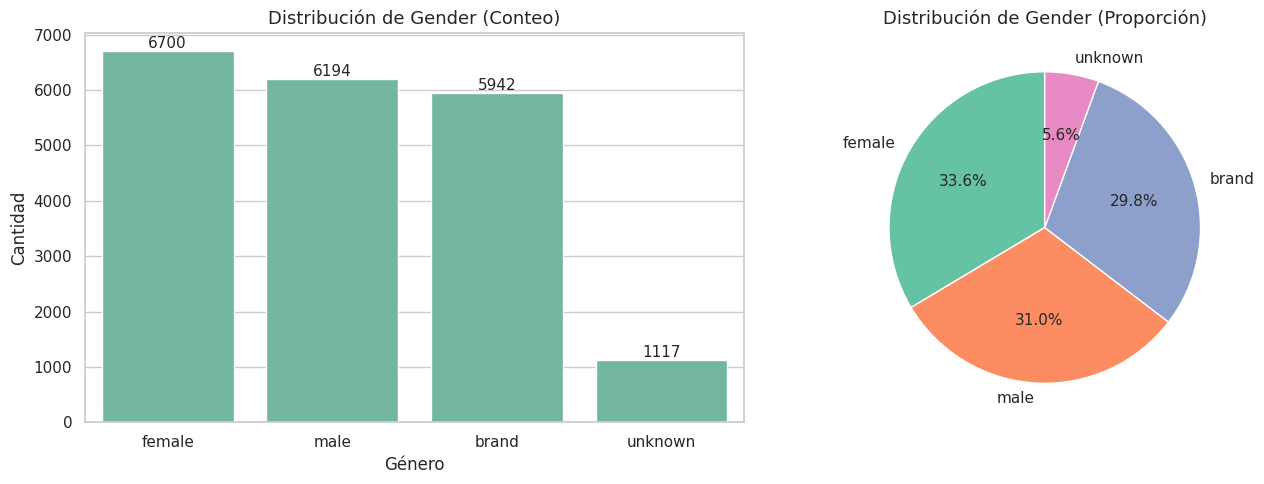

In [10]:
# Gráfico de barras - distribución de gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo absoluto
order = df["gender"].value_counts().index
sns.countplot(data=df, x="gender", order=order, ax=axes[0])
axes[0].set_title("Distribución de Gender (Conteo)", fontsize=13)
axes[0].set_xlabel("Género")
axes[0].set_ylabel("Cantidad")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha="center", va="bottom", fontsize=11)

# Proporción (pie chart)
colors = sns.color_palette("Set2", n_colors=len(order))
df["gender"].value_counts().plot.pie(autopct="%1.1f%%", colors=colors, ax=axes[1],
                                      startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Distribución de Gender (Proporción)", fontsize=13)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

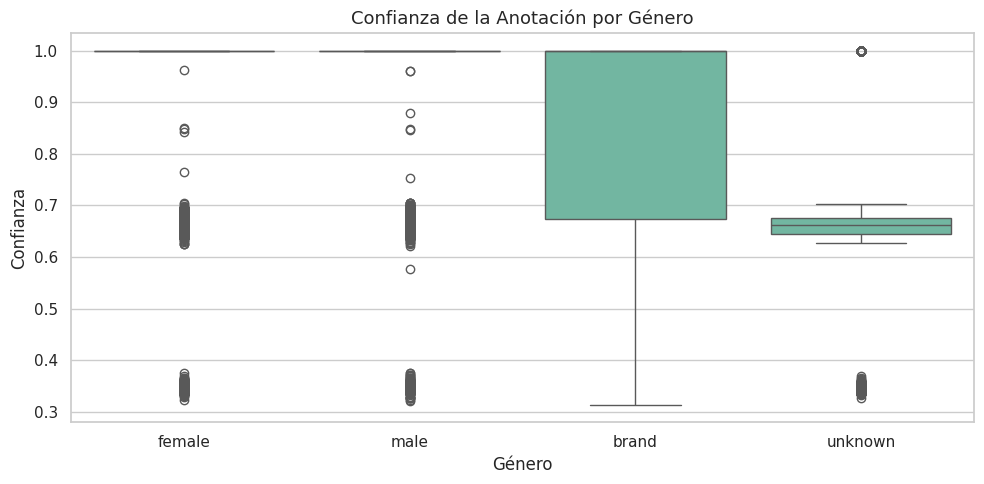

In [11]:
# Confianza de la anotación por categoría de gender
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="gender", y="gender:confidence", order=order, ax=ax)
ax.set_title("Confianza de la Anotación por Género", fontsize=13)
ax.set_xlabel("Género")
ax.set_ylabel("Confianza")
plt.tight_layout()
plt.show()

## 6. Distribución de Variables Numéricas

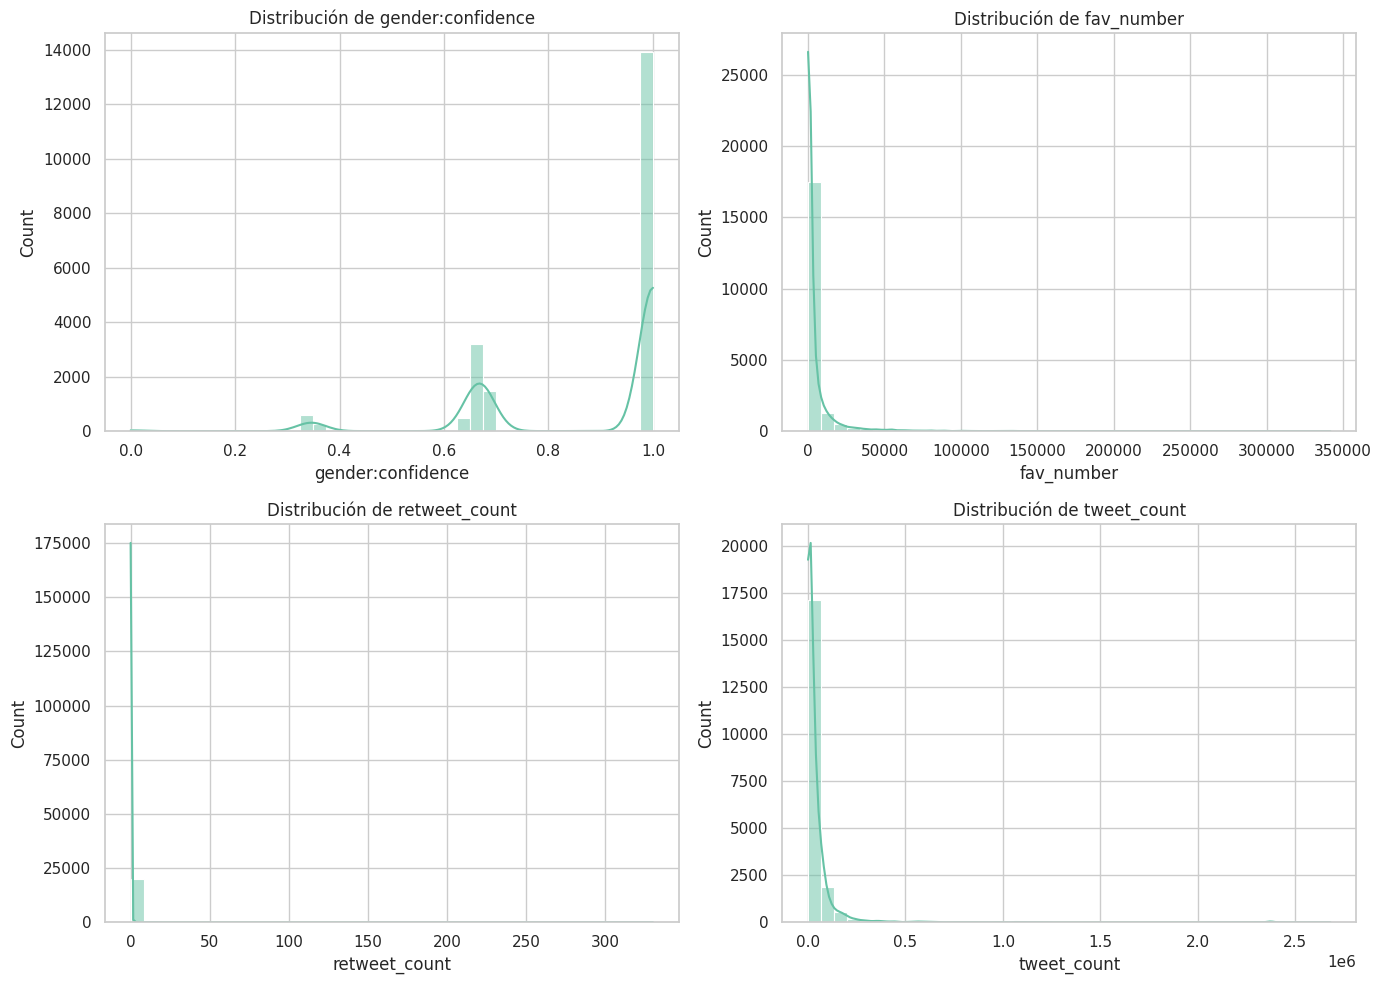

In [12]:
# Seleccionar columnas numéricas relevantes
num_cols = ["gender:confidence", "fav_number", "retweet_count", "tweet_count"]
num_cols_available = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols_available):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], bins=40)
    axes[i].set_title(f"Distribución de {col}", fontsize=12)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

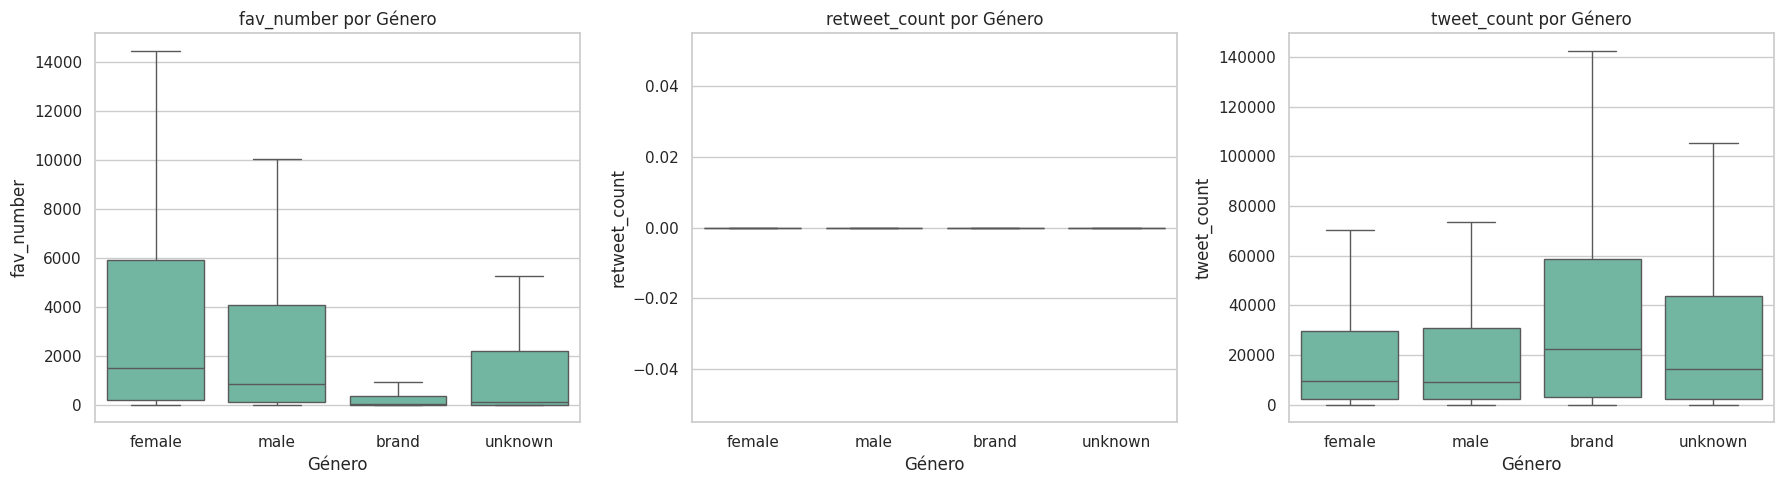

In [13]:
# Boxplots de variables numéricas por gender
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
box_cols = ["fav_number", "retweet_count", "tweet_count"]
box_cols_available = [c for c in box_cols if c in df.columns]

for i, col in enumerate(box_cols_available):
    sns.boxplot(data=df, x="gender", y=col, order=order, ax=axes[i], showfliers=False)
    axes[i].set_title(f"{col} por Género", fontsize=12)
    axes[i].set_xlabel("Género")

plt.tight_layout()
plt.show()

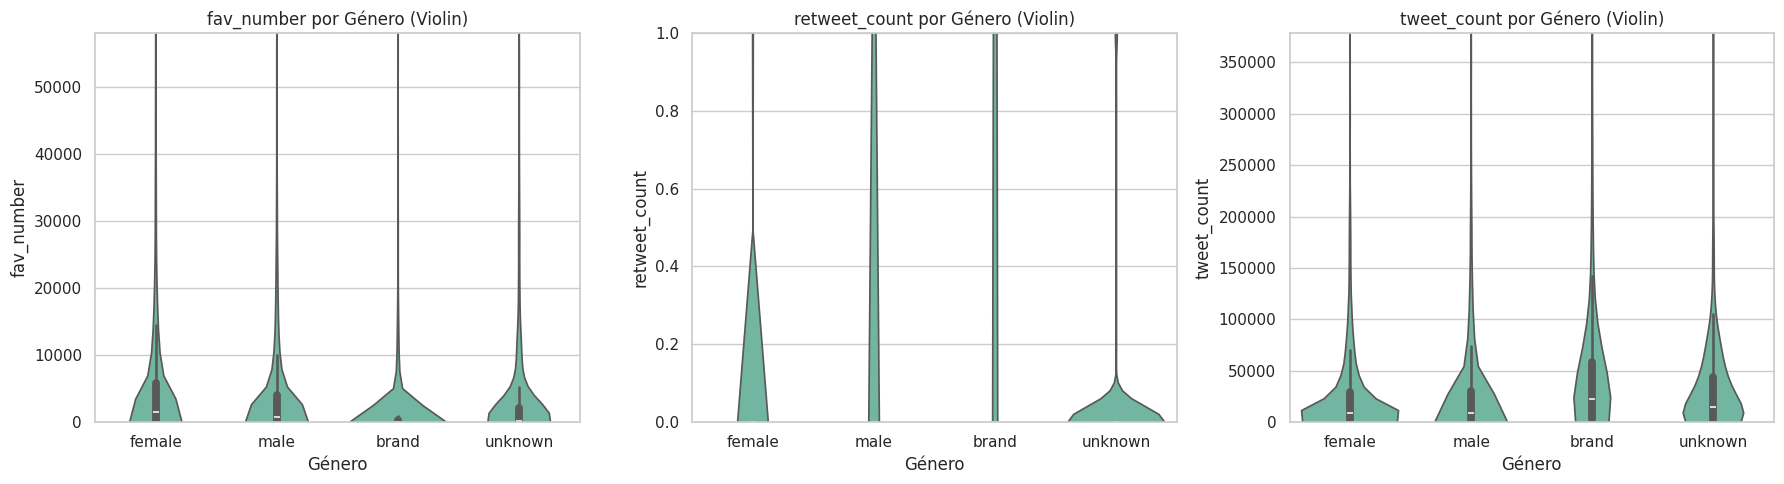

In [14]:
# Violin plots para ver la densidad de distribución por género
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(box_cols_available):
    sns.violinplot(data=df, x="gender", y=col, order=order, ax=axes[i], cut=0)
    axes[i].set_title(f"{col} por Género (Violin)", fontsize=12)
    axes[i].set_xlabel("Género")
    # Limitar el eje y para mejor visualización
    q99 = df[col].quantile(0.99)
    axes[i].set_ylim(0, q99)

plt.tight_layout()
plt.show()

## 7. Análisis de Correlaciones

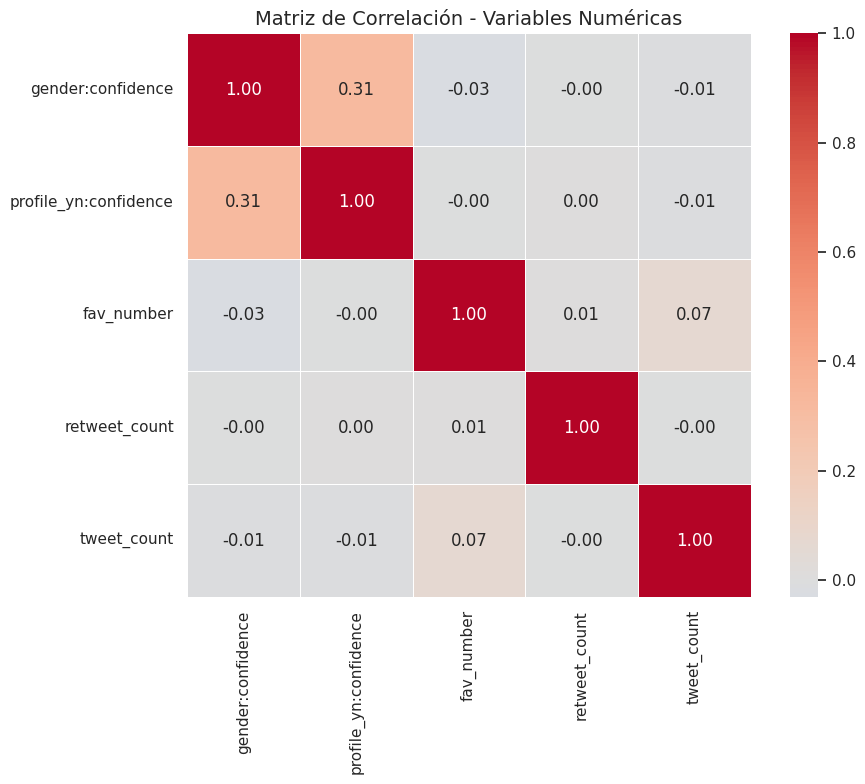

In [15]:
# Matriz de correlación de variables numéricas
corr_cols = ["gender:confidence", "profile_yn:confidence", "fav_number", 
             "retweet_count", "tweet_count"]
corr_cols_available = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols_available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de Correlación - Variables Numéricas", fontsize=14)
plt.tight_layout()
plt.show()

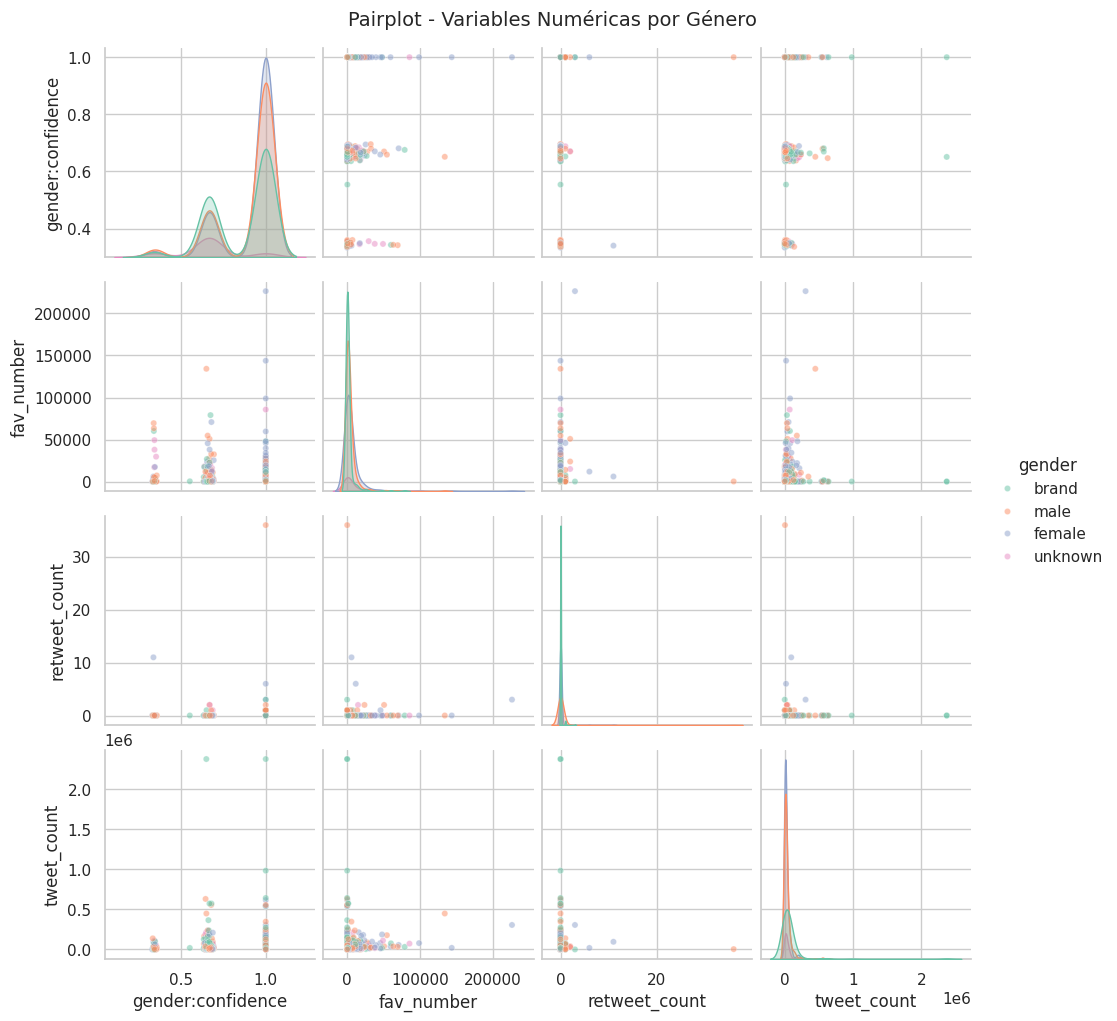

In [16]:
# Pairplot de variables numéricas coloreadas por gender
pair_cols = ["gender:confidence", "fav_number", "retweet_count", "tweet_count", "gender"]
pair_cols_available = [c for c in pair_cols if c in df.columns]

# Muestreo para que el pairplot no sea demasiado lento
df_sample = df[pair_cols_available].dropna().sample(n=min(1000, len(df)), random_state=SEED)

g = sns.pairplot(df_sample, hue="gender", diag_kind="kde", 
                 plot_kws={"alpha": 0.5, "s": 20},
                 height=2.5)
g.figure.suptitle("Pairplot - Variables Numéricas por Género", y=1.02, fontsize=14)
plt.show()

## 8. Análisis de Variables Categóricas

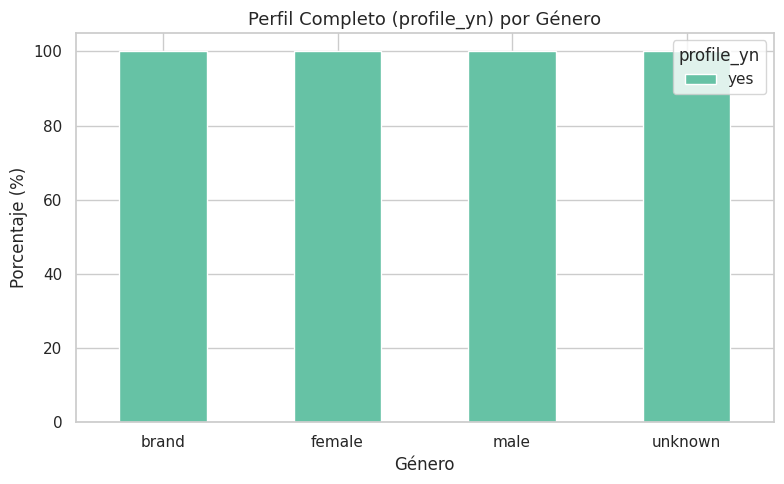

In [17]:
# Distribución de profile_yn por gender
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df["gender"], df["profile_yn"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Perfil Completo (profile_yn) por Género", fontsize=13)
ax.set_xlabel("Género")
ax.set_ylabel("Porcentaje (%)")
ax.legend(title="profile_yn")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

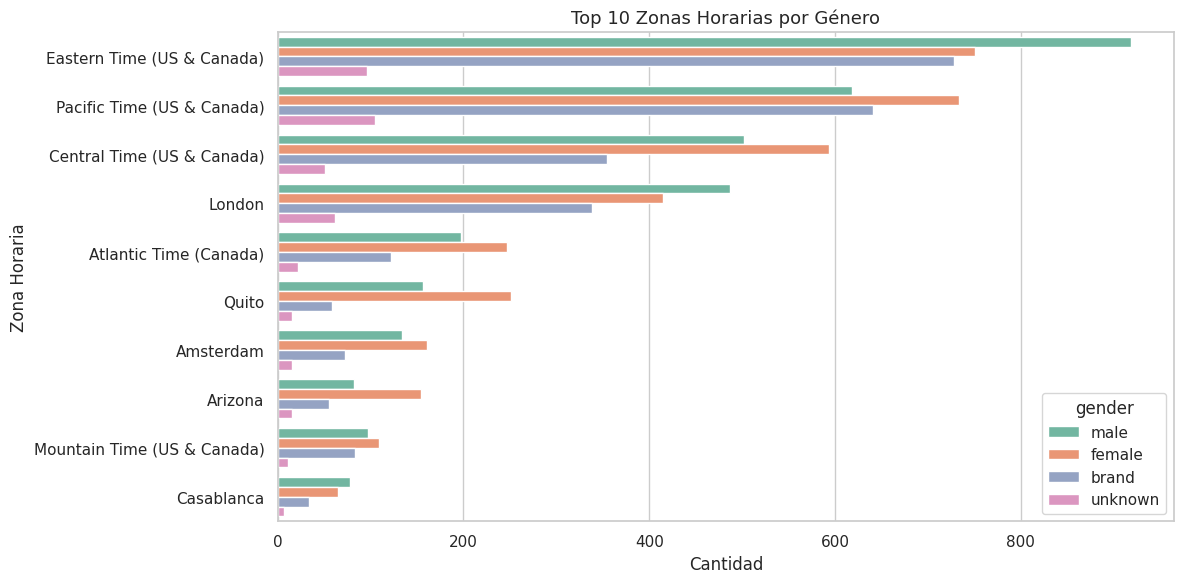

In [18]:
# Top 10 zonas horarias por género
fig, ax = plt.subplots(figsize=(12, 6))
top_tz = df["user_timezone"].value_counts().head(10).index
df_tz = df[df["user_timezone"].isin(top_tz)]
sns.countplot(data=df_tz, y="user_timezone", hue="gender", 
              order=top_tz, ax=ax)
ax.set_title("Top 10 Zonas Horarias por Género", fontsize=13)
ax.set_xlabel("Cantidad")
ax.set_ylabel("Zona Horaria")
plt.tight_layout()
plt.show()

## 9. Análisis de Texto (descripción del perfil)

La longitud de la descripción del perfil puede ser un indicador útil para la clasificación de género.

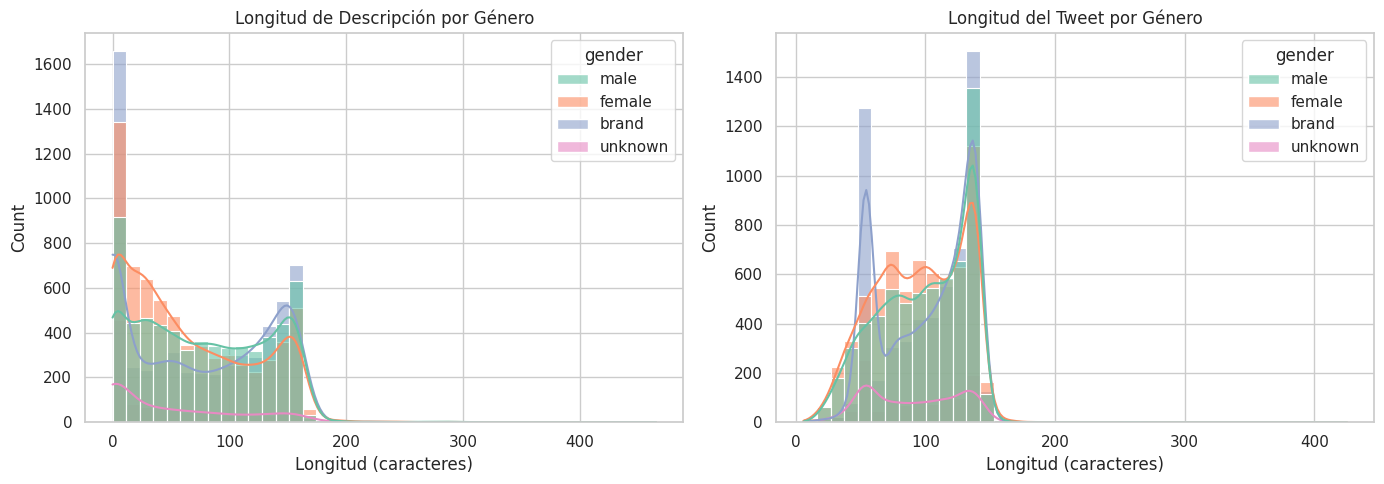

In [19]:
# Longitud de la descripción del perfil por género
df["desc_length"] = df["description"].fillna("").str.len()
df["text_length"] = df["text"].fillna("").str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="desc_length", hue="gender", kde=True, 
             ax=axes[0], bins=40, alpha=0.6)
axes[0].set_title("Longitud de Descripción por Género", fontsize=12)
axes[0].set_xlabel("Longitud (caracteres)")

sns.histplot(data=df, x="text_length", hue="gender", kde=True,
             ax=axes[1], bins=40, alpha=0.6)
axes[1].set_title("Longitud del Tweet por Género", fontsize=12)
axes[1].set_xlabel("Longitud (caracteres)")

plt.tight_layout()
plt.show()

## 10. Resumen y Conclusiones

### Sobre el dataset
- El dataset contiene **perfiles de Twitter** clasificados por género mediante crowdsourcing.
- Incluye información de perfil (descripción, colores, nombre), actividad (tweets, retweets, favoritos) y metadatos (ubicación, zona horaria).

### Sobre la variable objetivo `gender`
- Tiene **4 categorías**: `male`, `female`, `brand` y `unknown`.
- La distribución entre clases permite verificar si existe desbalance que deba tratarse en la fase de modelado.
- La confianza de la anotación (`gender:confidence`) varía significativamente según la categoría.

### Sobre las correlaciones
- La matriz de correlación y el pairplot revelan las relaciones lineales entre las variables numéricas.
- Las variables de actividad (`tweet_count`, `retweet_count`, `fav_number`) pueden mostrar patrones distintos por categoría de género.

### Siguientes pasos
- Preprocesamiento de datos: limpieza de valores faltantes y encoding de variables categóricas.
- Feature engineering: extraer características de texto (descripción, tweets).
- Modelado: entrenar clasificadores para predecir `gender`.